## Source

- Energy consumption data obtained from Appendix I: Detailed Energy Balance from page 52 of the 2023 MEMD Statistical Abstract
- Energy consumption transition data obtained from Uganda Energy Transition Plan Figure 2.3 in page 30

NOTE: We can select as sector_type Non-specified (HH, Com. & PS., Agri.) however we chose "Commercial and Public Services" to get some data. The consumptions are 0 anyways.

In [3]:
import sys
import warnings
warnings.filterwarnings("ignore")

dir_git = "/Users/usuario/git/sisepuede"
if dir_git not in sys.path:
    sys.path.append(dir_git)

import numpy as np
import pandas as pd
import os
from utils.utils import *
import utils.common_data_needs as cdn




In [7]:
%load_ext autoreload
%autoreload 2

In [8]:
edau = EDAUtils()
gu = GeneralUtils()

In [9]:
# Set up paths
CURRENT_DIR_PATH = os.getcwd()
OUTPUT_DATA_DIR_PATH = os.path.join(CURRENT_DIR_PATH, "output_data")
INPUT_DATA_DIR_PATH = os.path.join(CURRENT_DIR_PATH, "input_data")

In [10]:
# --- Select sector and set up years ---
fuel_share_sector_type  = "Residential"
scoe_type = "residential"
years_full = np.arange(2015, 2101)

In [11]:
# load final energy consumption by fuel data
fuel_share_df = pd.read_csv(os.path.join(INPUT_DATA_DIR_PATH, "inen","fuel_share_pj.csv"))
fuel_share_df

,Sector,Year,Oil,Coal,Natural_gas,Electricity,Bioenergy_and_waste
0,Industry,2015,30.00,3,0,8.0,110
1,Industry,2021,35.00,5,0,10.0,100
2,Industry,2030,47.00,15,15,50.0,60
3,Industry,2050,40.00,25,35,215.0,60
4,Industry,2070,35.00,20,25,250.0,50
5,Industry,2100,30.00,15,15,280.0,40
6,Residential,2015,0.05,0,0,0.8,450
7,Residential,2021,0.10,0,0,1.0,430
8,Residential,2030,60.00,0,0,50.0,120
9,Residential,2050,70.00,0,0,187.0,33


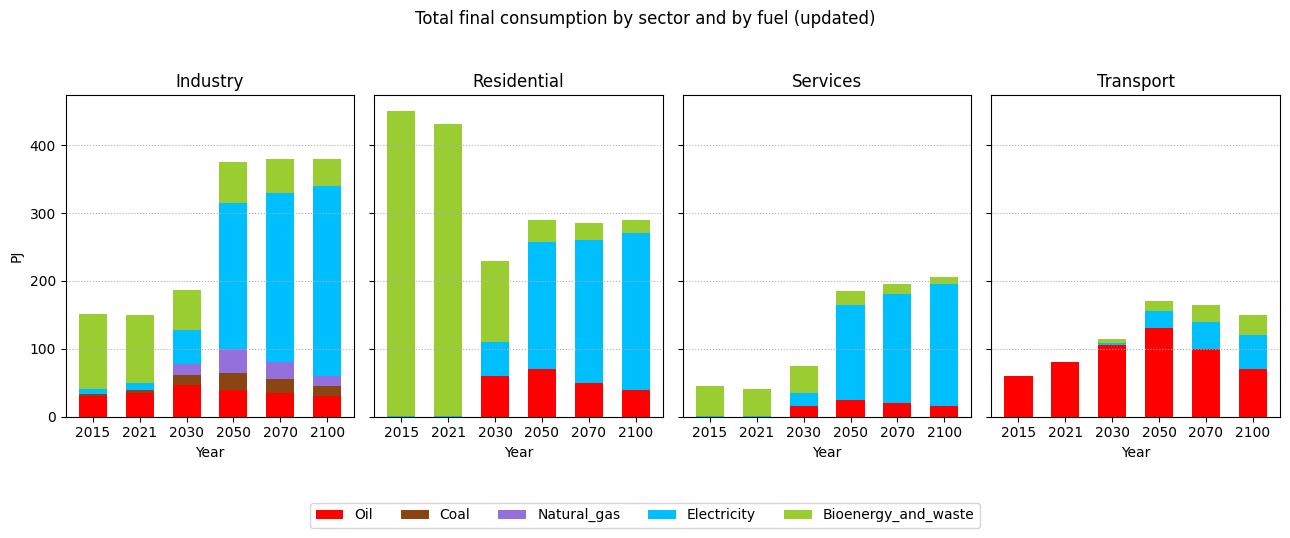

In [12]:
# Set color map matching the original plot
fuel_colors = {
    'Oil': 'red',
    'Coal': 'saddlebrown',
    'Natural_gas': 'mediumpurple',
    'Electricity': 'deepskyblue',
    'Bioenergy_and_waste': 'yellowgreen'
}

# Plotting
sectors = fuel_share_df['Sector'].unique()
years = [2015, 2021, 2030, 2050, 2070, 2100]  # Updated years to include 2100
fuels = ['Oil', 'Coal', 'Natural_gas', 'Electricity', 'Bioenergy_and_waste']

fig, axes = plt.subplots(1, len(sectors), figsize=(13,5), sharey=True)

bar_width = 0.6  # Wider bars

for i, sector in enumerate(sectors):
    ax = axes[i]
    sector_data = fuel_share_df[fuel_share_df['Sector'] == sector].sort_values('Year')
    x = range(len(years))
    bottom = [0] * len(years)
    for fuel in fuels:
        ax.bar(x, sector_data[fuel], width=bar_width, bottom=bottom, label=fuel if i == 0 else "", color=fuel_colors[fuel])
        bottom = [a + b for a, b in zip(bottom, sector_data[fuel])]
    ax.set_title(sector)
    ax.set_xticks(x)
    ax.set_xticklabels(years)
    if i == 0:
        ax.set_ylabel('PJ')
    ax.set_xlabel('Year')
    ax.grid(axis='y', linestyle=':')

fig.suptitle('Total final consumption by sector and by fuel (updated)')
fig.legend(fuels, loc='lower center', ncol=len(fuels), bbox_to_anchor=(0.5, -0.07))
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

In [13]:
# load final energy consumption by fuel data
consump_by_fuel_df = pd.read_csv(os.path.join(INPUT_DATA_DIR_PATH, "memd", "final_energy_consumption_by_fuel_uganda_2023.csv"))
consump_by_fuel_df.head()

,Sector,Oil Products Total,LPG,Gasoline,Jet Kerosene,Other Kerosene,Gas/Diesel Oil,Fuel oil,Solid Biofuels Total,Wood fuel,...,Other vegetal waste,Animal waste,Biomass briquettes,Charcoal,Biogas,Electricity Total,Hydro,Solar PV,Electricity,Total
0,Iron and steel,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,193,0,0,193,193.0
1,Chemical (including petrochemical),32,0,0,0,32,0,0,0,0,...,0,0,0,0,0,0,0,0,0,32.0
2,Non-metallic minerals,0,0,0,0,0,0,0,545,545,...,0,0,0,0,0,0,0,0,0,545.0
3,Machinery,394,0,97,0,0,297,0,0,0,...,0,0,0,0,0,0,0,0,0,394.0
4,"Food, beverages and tobacco",0,0,0,0,0,0,0,685,293,...,0,0,0,392,0,52,0,0,52,737.0


In [14]:
# Aggregate some fields
consump_by_fuel_df["Kerosene"] = consump_by_fuel_df["Jet Kerosene"] + consump_by_fuel_df["Other Kerosene"]
consump_by_fuel_df["Solid biomass"] = consump_by_fuel_df["Wood fuel"] + consump_by_fuel_df["Bagasse"] + consump_by_fuel_df["Rice husks"] + consump_by_fuel_df["Other vegetal waste"] +  consump_by_fuel_df["Animal waste"] + consump_by_fuel_df["Biomass briquettes"] + consump_by_fuel_df["Charcoal"]
consump_by_fuel_df["Electricity_and_hydro"] = consump_by_fuel_df["Electricity"] + consump_by_fuel_df["Hydro"]
consump_by_fuel_df["Diesel"] = consump_by_fuel_df["Gas/Diesel Oil"] * 0.90
consump_by_fuel_df["Furnace gas"] = consump_by_fuel_df["Gas/Diesel Oil"] * 0.10
consump_by_fuel_df["Natural gas"] = consump_by_fuel_df["Gas/Diesel Oil"] * 0.00
consump_by_fuel_df.head()

,Sector,Oil Products Total,LPG,Gasoline,Jet Kerosene,Other Kerosene,Gas/Diesel Oil,Fuel oil,Solid Biofuels Total,Wood fuel,...,Hydro,Solar PV,Electricity,Total,Kerosene,Solid biomass,Electricity_and_hydro,Diesel,Furnace gas,Natural gas
0,Iron and steel,0,0,0,0,0,0,0,0,0,...,0,0,193,193.0,0,0,193,0.0,0.0,0.0
1,Chemical (including petrochemical),32,0,0,0,32,0,0,0,0,...,0,0,0,32.0,32,0,0,0.0,0.0,0.0
2,Non-metallic minerals,0,0,0,0,0,0,0,545,545,...,0,0,0,545.0,0,545,0,0.0,0.0,0.0
3,Machinery,394,0,97,0,0,297,0,0,0,...,0,0,0,394.0,0,0,0,267.3,29.7,0.0
4,"Food, beverages and tobacco",0,0,0,0,0,0,0,685,293,...,0,0,52,737.0,0,685,52,0.0,0.0,0.0


In [15]:

sector_type = "Households"

In [16]:
# Filter consumption data for the specific sector
consump_by_fuel_df_filtered = consump_by_fuel_df[consump_by_fuel_df["Sector"] == sector_type]
consump_by_fuel_df_filtered

,Sector,Oil Products Total,LPG,Gasoline,Jet Kerosene,Other Kerosene,Gas/Diesel Oil,Fuel oil,Solid Biofuels Total,Wood fuel,...,Hydro,Solar PV,Electricity,Total,Kerosene,Solid biomass,Electricity_and_hydro,Diesel,Furnace gas,Natural gas
16,Households,33,25,0,0,8,0,0,7861,4608,...,0,0,84,8031.0,8,7861,84,0.0,0.0,0.0


In [17]:
# Map logical fuel names to (numerator column, denominator column)
fuel_share_map = {
    "Diesel": ("Diesel", "Oil Products Total"),
    "Kerosene": ("Kerosene", "Oil Products Total"),
    "Oil": ("Fuel oil", "Oil Products Total"),
    "Gasoline": ("Gasoline", "Oil Products Total"),
    "Hydrocarbon_Gas_Liquids": ("LPG", "Oil Products Total"),
    "Electricity": ("Electricity_and_hydro", "Electricity Total"),
    "Solar": ("Solar PV", "Electricity Total"),
    "Solid Biomass": ("Solid biomass", "Solid Biofuels Total"),
}

SMALL = 1e-6

fuel_type_shares = {}
for fuel, (num_col, denom_col) in fuel_share_map.items():
    num = consump_by_fuel_df_filtered[num_col].values[0]
    denom = consump_by_fuel_df_filtered[denom_col].values[0]
    # Use max to ensure denom is not zero (prevents inf)
    fuel_type_shares[fuel] = num / max(denom, SMALL)

print(fuel_type_shares)


{'Diesel': np.float64(0.0), 'Kerosene': np.float64(0.24242424242424243), 'Oil': np.float64(0.0), 'Gasoline': np.float64(0.0), 'Hydrocarbon_Gas_Liquids': np.float64(0.7575757575757576), 'Electricity': np.float64(1.0), 'Solar': np.float64(0.0), 'Solid Biomass': np.float64(1.0)}


In [18]:
agg_map = {
    "Oil": ["Diesel", "Kerosene", "Oil", "Gasoline", "Hydrocarbon_Gas_Liquids"],
    "Electricity": ["Electricity", "Solar"],
    "Bioenergy_and_waste": ["Solid Biomass"],
    # The following are handled manually
    "Coal": ["Coal", "Coke"],
    "Natural_gas": ["Natural gas", "Furnace gas"],
}

manual_frac_in_agg = {}

for agg, subfuels in agg_map.items():
    if agg in ["Oil", "Electricity", "Bioenergy_and_waste"]:
        # For these, populate using fuel_type_shares, setting 0 if not found
        manual_frac_in_agg[agg] = {
            subfuel: fuel_type_shares.get(subfuel, 0) for subfuel in subfuels
        }
manual_frac_in_agg["Coal"] = {"Coal": 1, "Coke": 0}
manual_frac_in_agg["Natural_gas"] = {"Natural gas": 1, "Furnace gas": 0}
manual_frac_in_agg["Hydrogen"] = {"Hydrogen": 0}

manual_frac_in_agg

{'Oil': {'Diesel': np.float64(0.0),
  'Kerosene': np.float64(0.24242424242424243),
  'Oil': np.float64(0.0),
  'Gasoline': np.float64(0.0),
  'Hydrocarbon_Gas_Liquids': np.float64(0.7575757575757576)},
 'Electricity': {'Electricity': np.float64(1.0), 'Solar': np.float64(0.0)},
 'Bioenergy_and_waste': {'Solid Biomass': np.float64(1.0)},
 'Coal': {'Coal': 1, 'Coke': 0},
 'Natural_gas': {'Natural gas': 1, 'Furnace gas': 0},
 'Hydrogen': {'Hydrogen': 0}}

In [291]:
# Prepare fuel_share_df for the selected sector and interpolate
sector_mask = fuel_share_df["Sector"] == fuel_share_sector_type   # Change as needed
fuel_share_sector = fuel_share_df[sector_mask].copy()
print(fuel_share_sector)



# add in 2023 numbers
df_unadj = pd.read_csv(cdn._PATH_BASE_RAW_DATA)
ktoe_to_pj = cdn.get_pj_per_ktoe(df_unadj, )

dict_vals_from_memd = {
    "Oil": 33,
    "Electricity": 84,
    "Bioenergy_and_waste": 7862,
}

dict_new_row = {}
for k in fuel_share_sector.columns:
    if k == "Sector":
        val = [fuel_share_sector_type, fuel_share_sector_type]
    elif k == "Year":
        val = [2023, 2024]
    else:
        val = dict_vals_from_memd.get(k, 0)*ktoe_to_pj
        val = [val, val]
        

    dict_new_row.update({k: val})

dict_new_row = pd.DataFrame(dict_new_row)

fuel_share_sector = (
    pd.concat(
        [
            fuel_share_sector,
            dict_new_row
        ]
    )
    .sort_values(by = ["Year"])
    .reset_index(drop = True, )
)

# cut oil in half
fuel_share_sector["Oil"] /= 2

         Sector  Year    Oil  Coal  Natural_gas  Electricity  \
6   Residential  2015   0.05     0            0          0.8   
7   Residential  2021   0.10     0            0          1.0   
8   Residential  2030  60.00     0            0         50.0   
9   Residential  2050  70.00     0            0        187.0   
10  Residential  2070  50.00     0            0        210.0   
11  Residential  2100  40.00     0            0        230.0   

    Bioenergy_and_waste  
6                   450  
7                   430  
8                   120  
9                    33  
10                   25  
11                   20  


(2020.0, 2050.0)

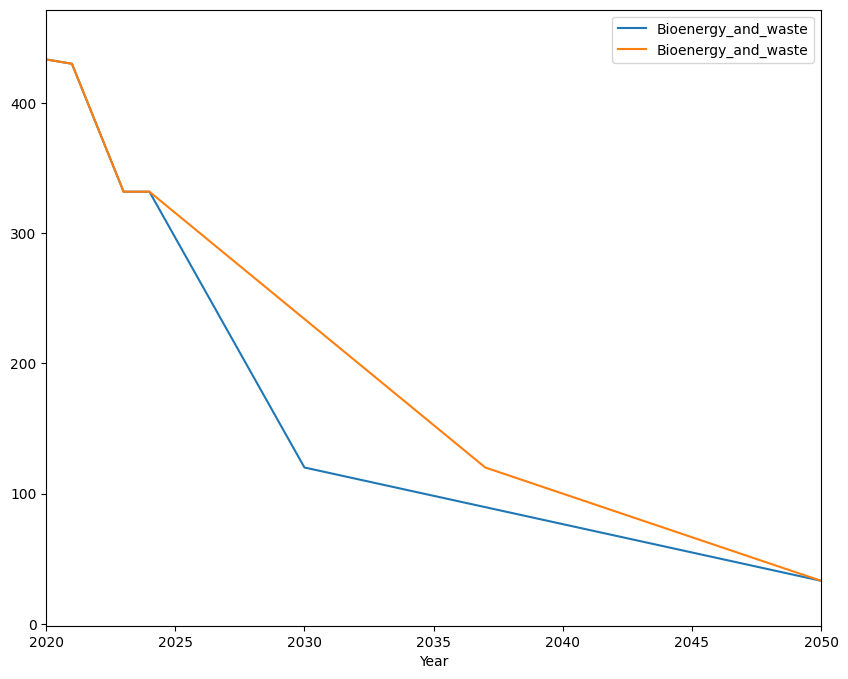

In [292]:
#
#    JAMES 20260505--MANUALLY ADJUST THE BIOENERGY TO SLOW THE TRANSITION
#
fuel_old = fuel_share_sector[["Year", "Bioenergy_and_waste"]].copy()
"""
vals_new = [
    450, 
    430, 
    dict_new_row["Bioenergy_and_waste"].iloc[0],
    dict_new_row["Bioenergy_and_waste"].iloc[0],
    200, 
    48, 
    25, 
    20
]
fuel_share_sector["Bioenergy_and_waste"] = vals_new
"""
# push back the reduction
w = np.where(fuel_share_sector["Year"].to_numpy() == 2030)[0][0]
fuel_share_sector["Year"].iloc[w] = 2037

# add a row to 

fig, ax = plt.subplots(figsize = (10, 8))
fuel_old.plot(ax = ax, label = "Old", x = "Year", )
fuel_share_sector[["Year", "Bioenergy_and_waste"]].plot(ax = ax, label = "New", x = "Year")

ax.set_xlim(2020, 2050)


In [293]:
# --- Filter, interpolate, and ffill high-level shares ---
agg_cols = ["Oil", "Coal", "Natural_gas", "Electricity", "Bioenergy_and_waste"]
sector_df = fuel_share_sector.copy()#fuel_share_df[fuel_share_df["Sector"] == fuel_share_sector_type].copy()
sector_df = sector_df.set_index("Year").reindex(years_full)
sector_df[agg_cols] = sector_df[agg_cols].interpolate(method="linear").ffill()
sector_df["Year"] = sector_df.index

In [294]:
sector_df[sector_df["Year"].isin([2020])]

,Sector,Oil,Coal,Natural_gas,Electricity,Bioenergy_and_waste,Year
Year,,,,,,,
2020,NaN,0.045833,0.0,0.0,0.966667,433.333333,2020


In [295]:
detailed_fuels = [
    "Diesel", "Kerosene", "Oil", "Gasoline", "Hydrocarbon_Gas_Liquids",
    "Coal", "Coke",
    "Natural gas", "Furnace gas",
    "Electricity", "Solar",
    "Solid biomass",
    "Hydrogen"
]


In [296]:
output_rows = []
for year, row in sector_df.iterrows():
    out_row = {"year": int(year)}
    # For each aggregate, allocate to detailed fuels
    for agg, details in manual_frac_in_agg.items():
        agg_val = row.get(agg, 0)
        for fuel, frac in details.items():
            colname = f"frac_scoe_heat_energy_{scoe_type}_{fuel.lower().replace(' ', '_')}"
            out_row[colname] = agg_val * frac
    # Hydrogen: always zero for Uganda in this context
    out_row[f"frac_scoe_heat_energy_{scoe_type}_hydrogen"] = 0
    output_rows.append(out_row)

result_df = pd.DataFrame(output_rows)

In [297]:
# --- Normalize so fractions sum to 1 (excluding year) ---
detailed_cols = [col for col in result_df.columns if col != "year"]
result_df[detailed_cols] = result_df[detailed_cols].div(result_df[detailed_cols].sum(axis=1), axis=0)


In [298]:
# --- Order columns ---
result_df = result_df[["year"] + detailed_cols]

In [299]:
# # Fill values before 2021 with the first known year (2021) using ffill() and bbfill()
# result_df[detailed_cols] = (
#     result_df[detailed_cols]
#     .ffill()
#     .bfill()
# )



In [300]:
result_df.tail()

,year,frac_scoe_heat_energy_residential_diesel,frac_scoe_heat_energy_residential_kerosene,frac_scoe_heat_energy_residential_oil,frac_scoe_heat_energy_residential_gasoline,frac_scoe_heat_energy_residential_hydrocarbon_gas_liquids,frac_scoe_heat_energy_residential_electricity,frac_scoe_heat_energy_residential_solar,frac_scoe_heat_energy_residential_solid_biomass,frac_scoe_heat_energy_residential_coal,frac_scoe_heat_energy_residential_coke,frac_scoe_heat_energy_residential_natural_gas,frac_scoe_heat_energy_residential_furnace_gas,frac_scoe_heat_energy_residential_hydrogen
81,2096,0.0,0.018648,0.0,0.0,0.058275,0.846154,0.0,0.076923,0.0,0.0,0.0,0.0,0.0
82,2097,0.0,0.018475,0.0,0.0,0.057733,0.847584,0.0,0.076208,0.0,0.0,0.0,0.0,0.0
83,2098,0.0,0.018302,0.0,0.0,0.057193,0.849010,0.0,0.075495,0.0,0.0,0.0,0.0,0.0
84,2099,0.0,0.018129,0.0,0.0,0.056654,0.850433,0.0,0.074784,0.0,0.0,0.0,0.0,0.0
85,2100,0.0,0.017957,0.0,0.0,0.056117,0.851852,0.0,0.074074,0.0,0.0,0.0,0.0,0.0


In [301]:
# # project forward
# result_df_extended = gu.extend_projection(result_df, 2050 + 1, 2100)
# result_df_extended

In [302]:
# Drop fuel columns that are not included in frac_scoe
result_df = result_df.drop(
    columns=[
        f"frac_scoe_heat_energy_{scoe_type}_coke",
        f"frac_scoe_heat_energy_{scoe_type}_oil",
        f"frac_scoe_heat_energy_{scoe_type}_furnace_gas",
        f"frac_scoe_heat_energy_{scoe_type}_solar",
    ]
)

In [303]:
ind_safe = result_df["year"] <= 2023
ind_unsafe = result_df["year"] > 2023

df_sm_hp = result_df[ind_unsafe]
df_sm_hp = gu.smooth_timeseries_df(df_sm_hp, method="hp", hp_lambda=50)
df_sm_hp = pd.concat(
    [
        result_df[ind_safe],
        df_sm_hp
    ]
)

In [304]:
result_df_extended = df_sm_hp.copy()

## Validation

In [305]:
# check for duplicates
gu.check_duplicates(result_df_extended)

No duplicated years found in the DataFrame.
No duplicated rows found in the DataFrame.


In [306]:
# load global data
uga_global_df = pd.read_csv(os.path.join(INPUT_DATA_DIR_PATH, "sisepuede_raw_global_inputs_uganda.csv"))
uga_global_df.head()

,year,frac_lvst_mm_buffalo_anaerobic_digester,frac_lvst_mm_cattle_dairy_anaerobic_digester,frac_lvst_mm_cattle_nondairy_anaerobic_digester,frac_lvst_mm_chickens_anaerobic_digester,frac_lvst_mm_goats_anaerobic_digester,frac_lvst_mm_horses_anaerobic_digester,frac_lvst_mm_mules_anaerobic_digester,frac_lvst_mm_pigs_anaerobic_digester,frac_lvst_mm_sheep_anaerobic_digester,...,nemomod_entc_frac_min_share_production_pp_coal,nemomod_entc_frac_min_share_production_pp_coal_ccs,nemomod_entc_frac_min_share_production_pp_gas,nemomod_entc_frac_min_share_production_pp_gas_ccs,nemomod_entc_frac_min_share_production_pp_geothermal,nemomod_entc_frac_min_share_production_pp_nuclear,nemomod_entc_frac_min_share_production_pp_ocean,nemomod_entc_frac_min_share_production_pp_waste_incineration,nemomod_entc_frac_min_share_production_pp_wind,frac_trns_fuelmix_water_borne_gasoline
0,2015,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,2016,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,2017,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,2018,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,2019,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [307]:
print(gu.check_row_sums_to_one(result_df_extended))
result_df_extended.iloc[0:10]

(array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True]), np.True_)


,year,frac_scoe_heat_energy_residential_diesel,frac_scoe_heat_energy_residential_kerosene,frac_scoe_heat_energy_residential_gasoline,frac_scoe_heat_energy_residential_hydrocarbon_gas_liquids,frac_scoe_heat_energy_residential_electricity,frac_scoe_heat_energy_residential_solid_biomass,frac_scoe_heat_energy_residential_coal,frac_scoe_heat_energy_residential_natural_gas,frac_scoe_heat_energy_residential_hydrogen
0,2015,0.0,0.000013,0.0,0.000042,0.001775,0.998170,0.0,0.0,0.0
1,2016,0.0,0.000016,0.0,0.000049,0.001862,0.998073,0.0,0.0,0.0
2,2017,0.0,0.000018,0.0,0.000057,0.001951,0.997974,0.0,0.0,0.0
3,2018,0.0,0.000021,0.0,0.000064,0.002041,0.997874,0.0,0.0,0.0
4,2019,0.0,0.000023,0.0,0.000072,0.002133,0.997772,0.0,0.0,0.0
5,2020,0.0,0.000026,0.0,0.000080,0.002226,0.997669,0.0,0.0,0.0
6,2021,0.0,0.000028,0.0,0.000088,0.002320,0.997564,0.0,0.0,0.0
7,2022,0.0,0.000236,0.0,0.000737,0.005925,0.993102,0.0,0.0,0.0
8,2023,0.0,0.000502,0.0,0.001570,0.010549,0.987378,0.0,0.0,0.0
9,2024,0.0,0.000000,0.0,0.000000,0.004482,0.995518,0.0,0.0,0.0


Comparing frac_scoe_heat_energy_residential_diesel...


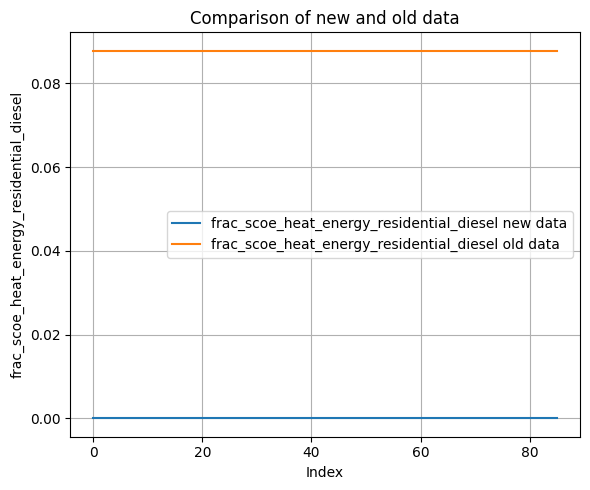

Comparing frac_scoe_heat_energy_residential_kerosene...


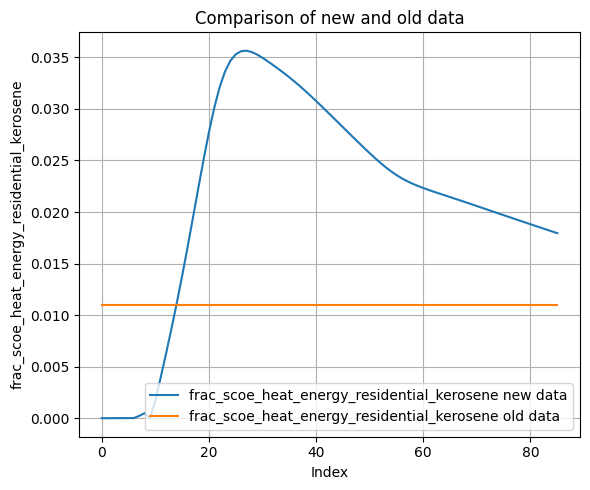

Comparing frac_scoe_heat_energy_residential_gasoline...


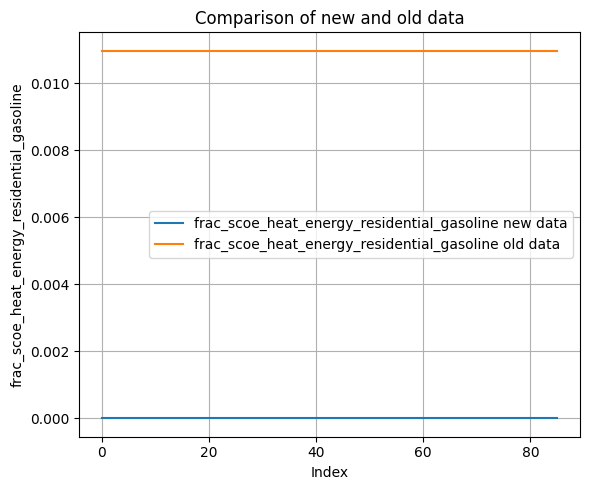

Comparing frac_scoe_heat_energy_residential_hydrocarbon_gas_liquids...


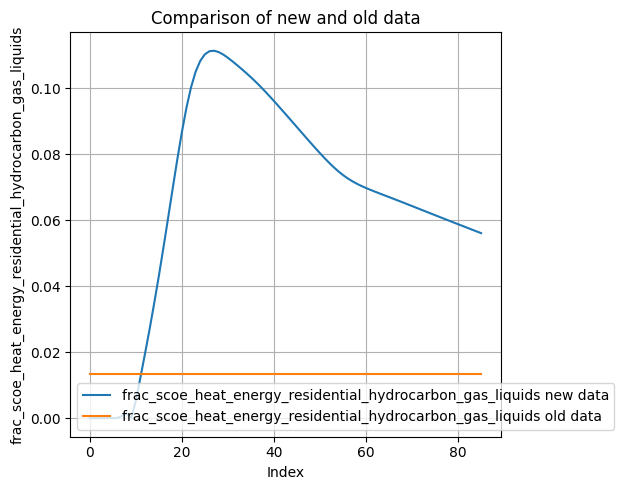

Comparing frac_scoe_heat_energy_residential_electricity...


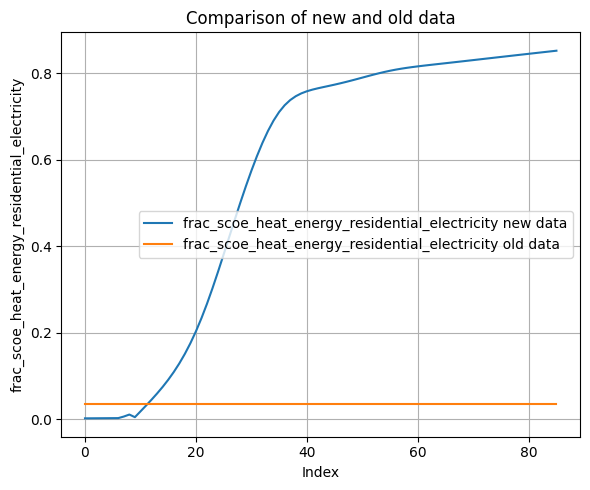

Comparing frac_scoe_heat_energy_residential_solid_biomass...


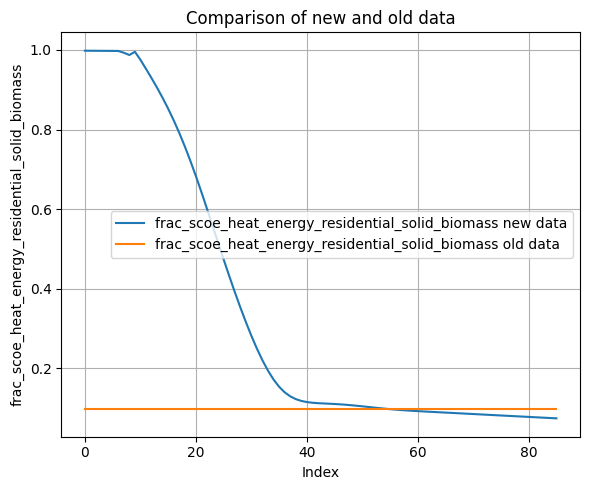

Comparing frac_scoe_heat_energy_residential_coal...


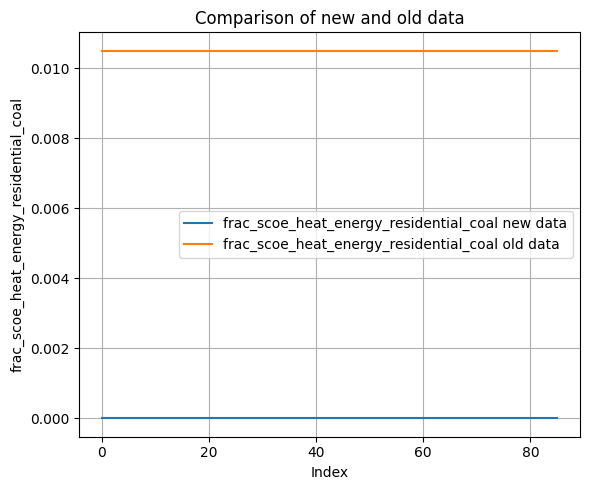

Comparing frac_scoe_heat_energy_residential_natural_gas...


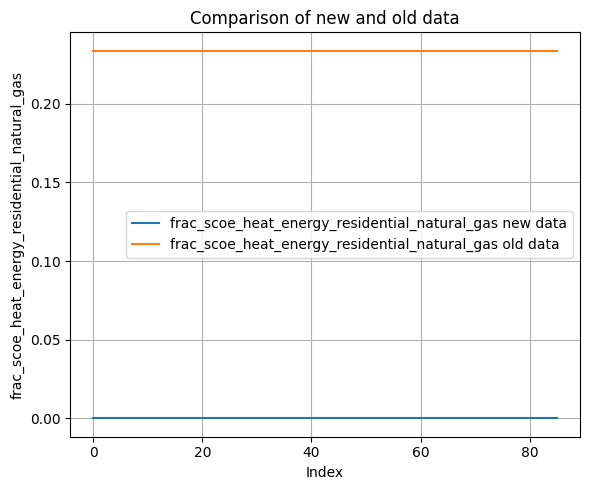

Comparing frac_scoe_heat_energy_residential_hydrogen...


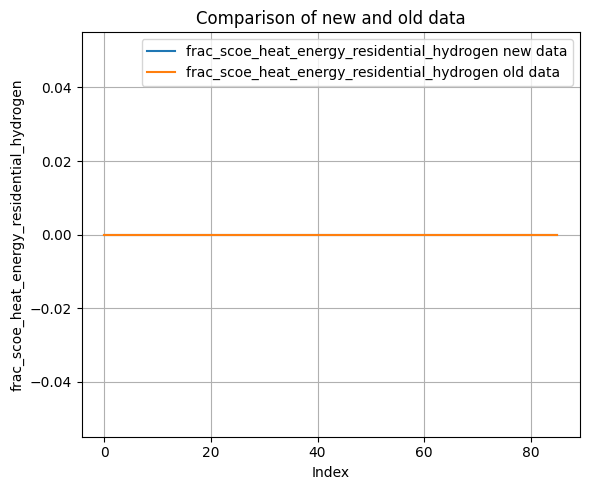

In [308]:
for var in result_df_extended.columns:
    if var != 'year':
        print(f"Comparing {var}...")
        edau.compare_variables(result_df_extended, uga_global_df, [var])

In [309]:
result_df_extended.to_csv(os.path.join(OUTPUT_DATA_DIR_PATH, f"frac_scoe_heat_energy_{scoe_type}.csv"), index=False)


<Axes: >

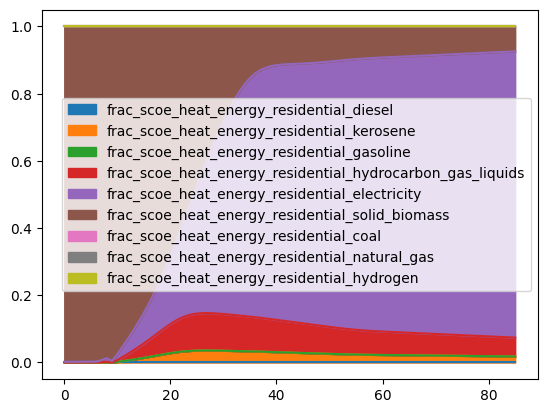

In [310]:
result_df_extended.drop(columns = "year").plot.area()



In [ ]:
df_u